# Understanding R² vs MSE/MAE: Why They Tell Different Stories

This notebook explains the fundamental difference between R² and MSE/MAE metrics, and why our models show improving MAE but degrading R².

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

np.random.seed(42)

## 1. Mathematical Definitions

Saved: graphs/mse_r2_definitions.png


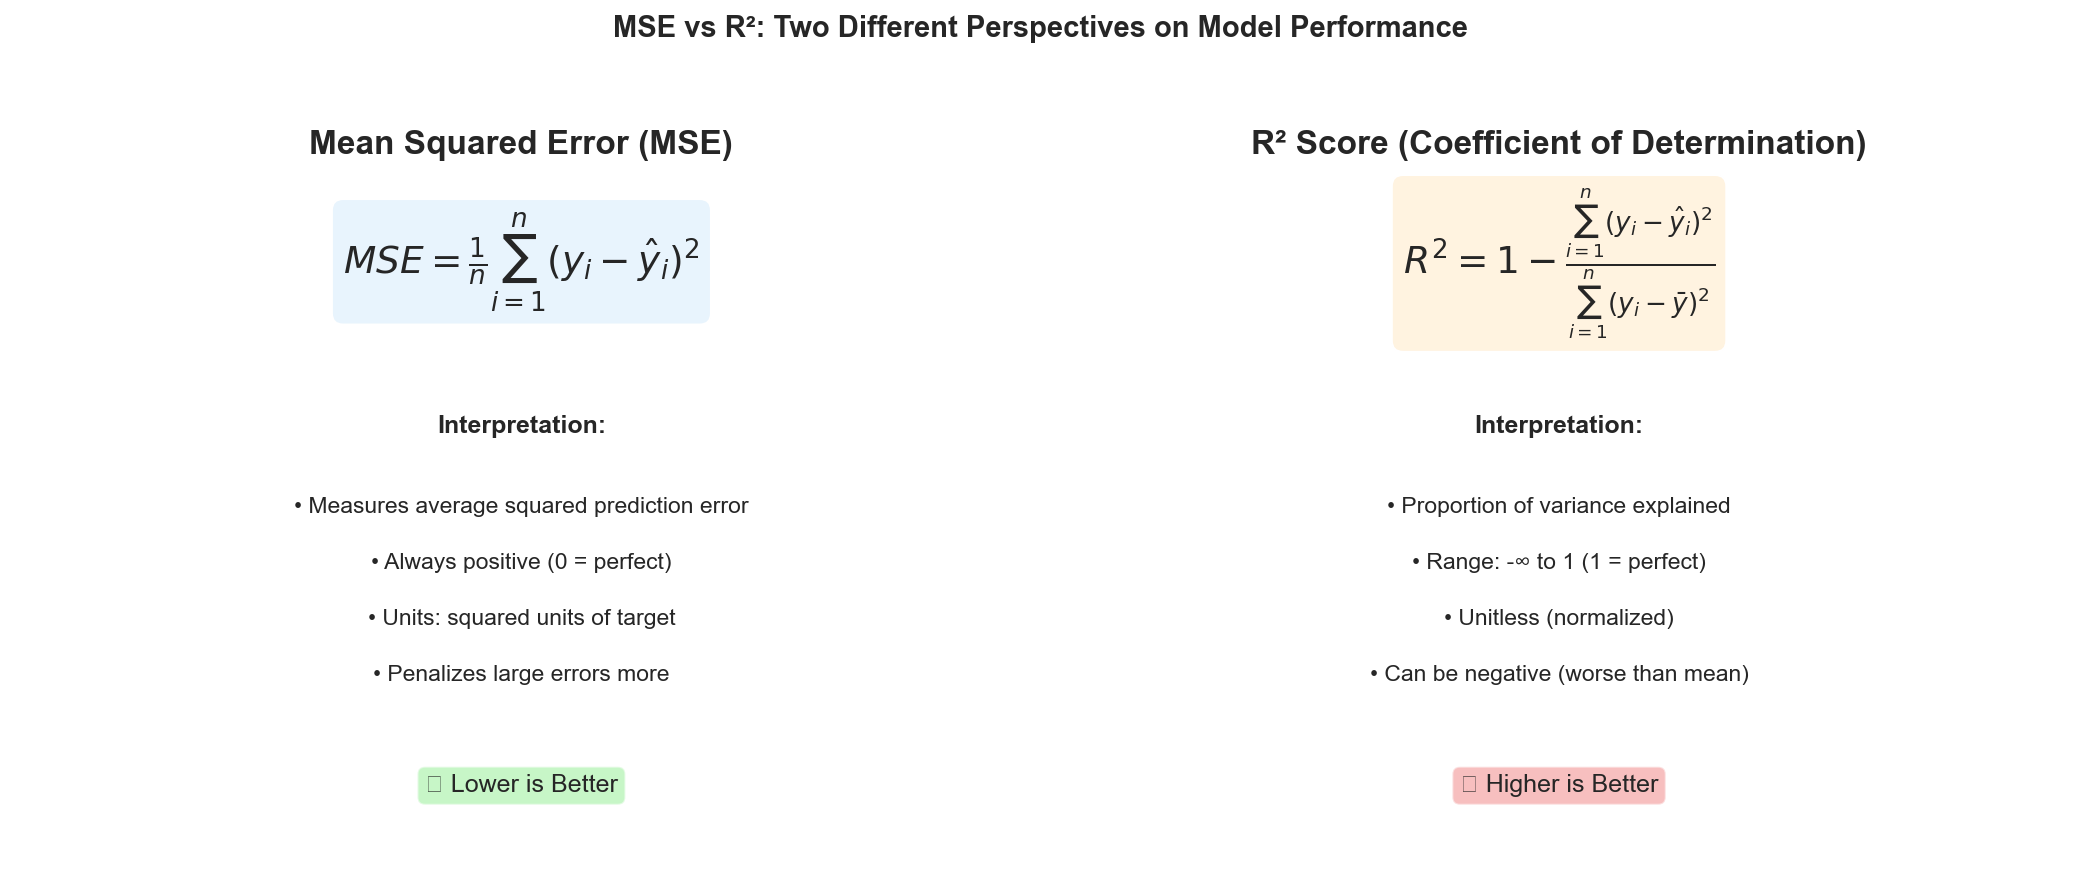

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.text(0.5, 0.9, 'Mean Squared Error (MSE)', fontsize=16, fontweight='bold', ha='center')
ax.text(0.5, 0.75, r'$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$', 
       fontsize=18, ha='center', bbox=dict(boxstyle='round', facecolor='#E8F4FD'))

ax.text(0.5, 0.55, 'Interpretation:', fontsize=12, fontweight='bold', ha='center')
ax.text(0.5, 0.45, '• Measures average squared prediction error', fontsize=11, ha='center')
ax.text(0.5, 0.38, '• Always positive (0 = perfect)', fontsize=11, ha='center')
ax.text(0.5, 0.31, '• Units: squared units of target', fontsize=11, ha='center')
ax.text(0.5, 0.24, '• Penalizes large errors more', fontsize=11, ha='center')

ax.text(0.5, 0.1, '📊 Lower is Better', fontsize=12, ha='center',
       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

ax = axes[1]
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.text(0.5, 0.9, 'R² Score (Coefficient of Determination)', fontsize=16, fontweight='bold', ha='center')
ax.text(0.5, 0.75, r'$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$', 
       fontsize=18, ha='center', bbox=dict(boxstyle='round', facecolor='#FFF3E0'))

ax.text(0.5, 0.55, 'Interpretation:', fontsize=12, fontweight='bold', ha='center')
ax.text(0.5, 0.45, '• Proportion of variance explained', fontsize=11, ha='center')
ax.text(0.5, 0.38, '• Range: -∞ to 1 (1 = perfect)', fontsize=11, ha='center')
ax.text(0.5, 0.31, '• Unitless (normalized)', fontsize=11, ha='center')
ax.text(0.5, 0.24, '• Can be negative (worse than mean)', fontsize=11, ha='center')

ax.text(0.5, 0.1, '📈 Higher is Better', fontsize=12, ha='center',
       bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

plt.suptitle('MSE vs R²: Two Different Perspectives on Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphs/mse_r2_definitions.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/mse_r2_definitions.png")
plt.show()

## 2. Visual Demonstration: Same MSE, Different R²

Saved: graphs/mse_vs_r2_examples.png


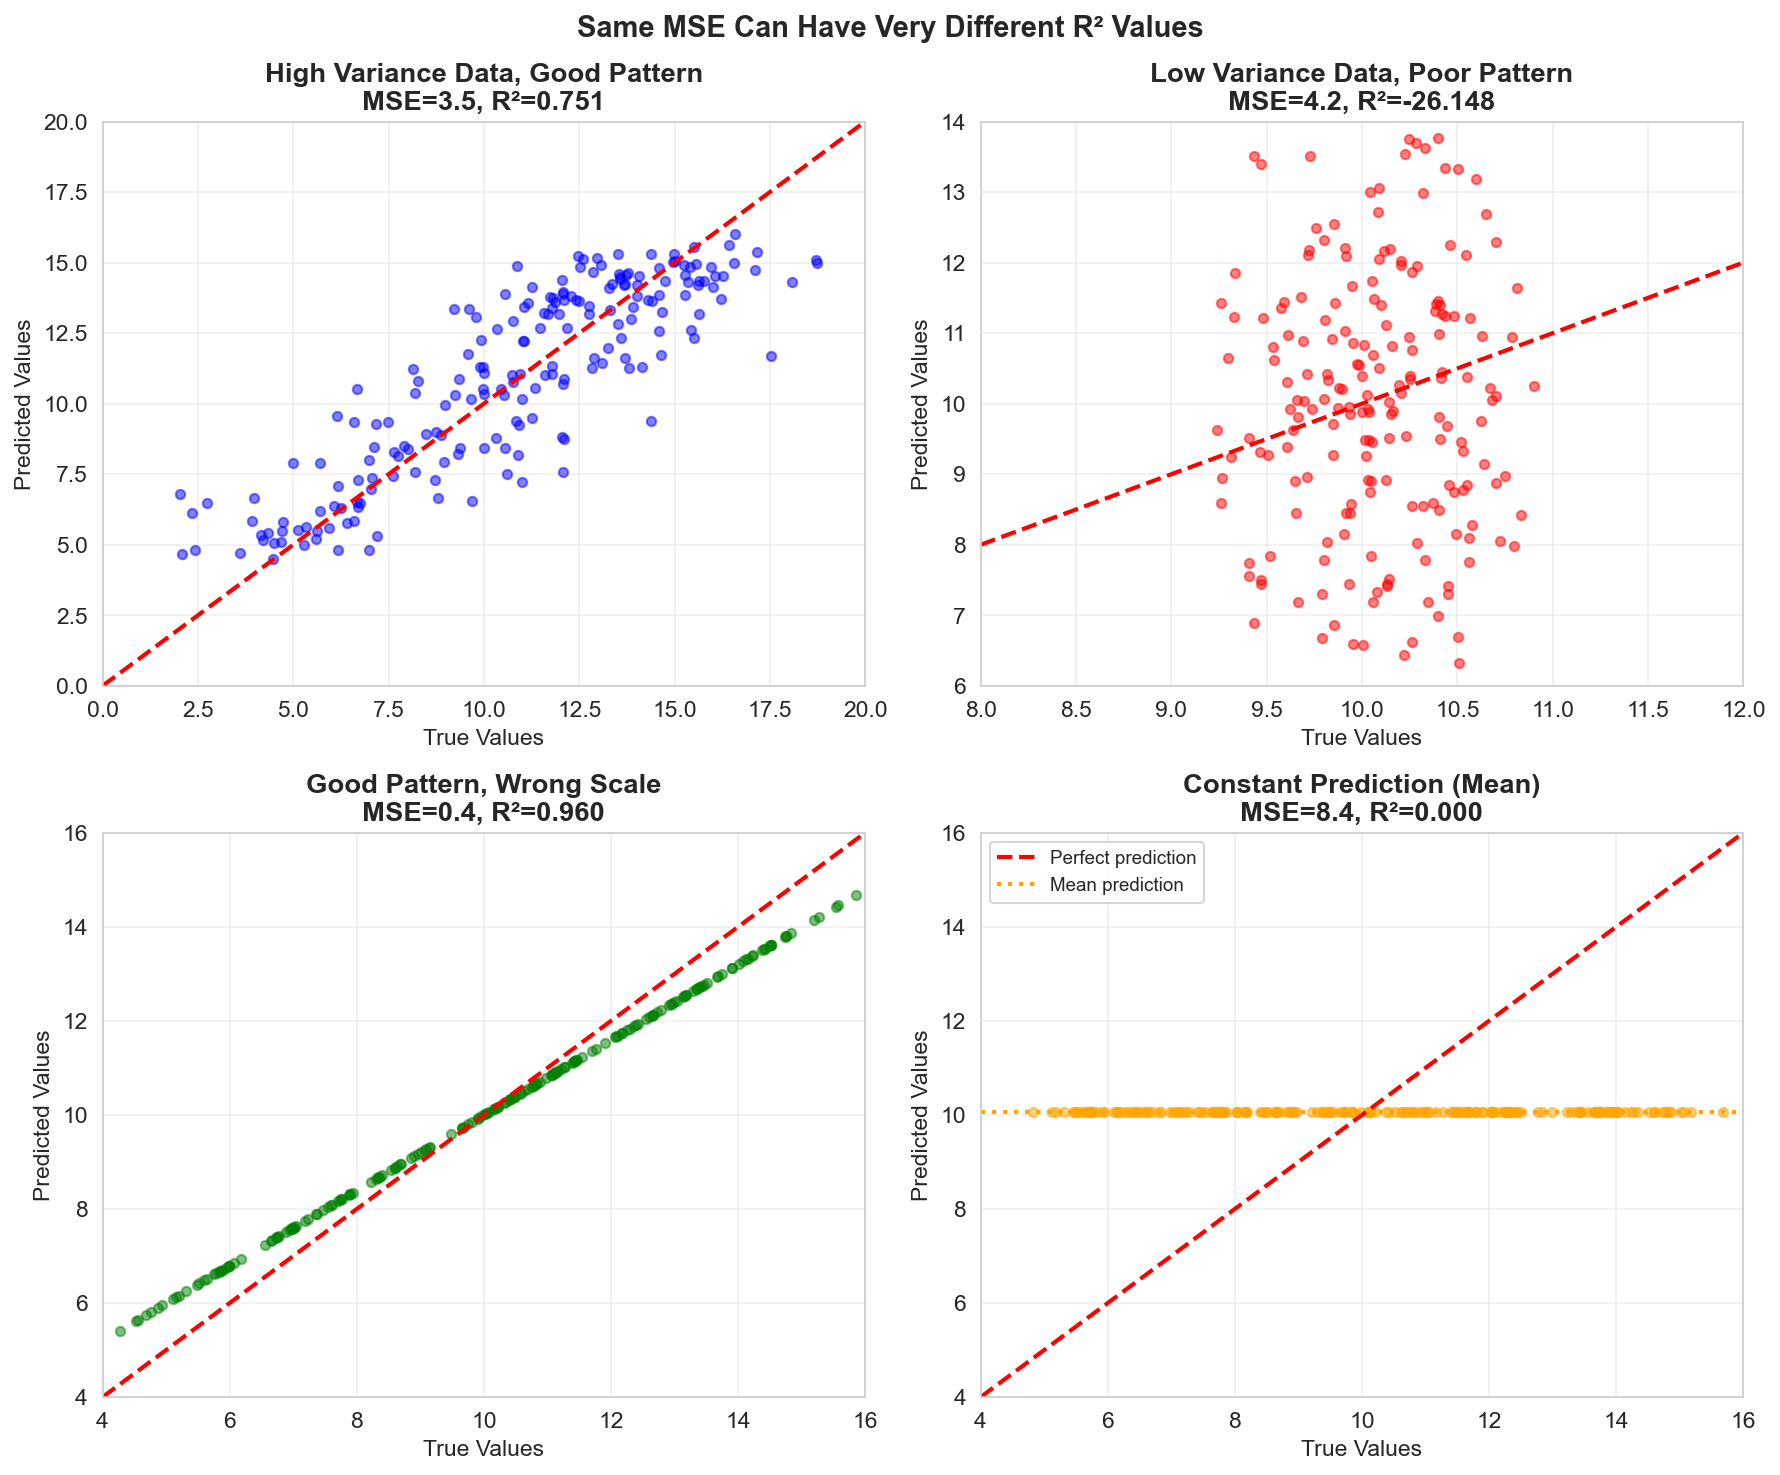

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

n_points = 200
x = np.linspace(0, 10, n_points)

y_true_high_var = 10 + 5 * np.sin(x) + np.random.normal(0, 2, n_points)
y_pred_good_pattern = 10 + 5 * np.sin(x) + np.random.normal(0, 0.5, n_points)
mse1 = mean_squared_error(y_true_high_var, y_pred_good_pattern)
r2_1 = r2_score(y_true_high_var, y_pred_good_pattern)

ax = axes[0, 0]
ax.scatter(y_true_high_var, y_pred_good_pattern, alpha=0.5, s=20, color='blue')
ax.plot([0, 20], [0, 20], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')
ax.set_title(f'High Variance Data, Good Pattern\nMSE={mse1:.1f}, R²={r2_1:.3f}', 
            fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 20)
ax.set_ylim(0, 20)

y_true_low_var = 10 + 0.5 * np.sin(x) + np.random.normal(0, 0.2, n_points)
y_pred_poor_pattern = 10 + np.random.normal(0, 2, n_points)
mse2 = mean_squared_error(y_true_low_var, y_pred_poor_pattern)
r2_2 = r2_score(y_true_low_var, y_pred_poor_pattern)

ax = axes[0, 1]
ax.scatter(y_true_low_var, y_pred_poor_pattern, alpha=0.5, s=20, color='red')
ax.plot([8, 12], [8, 12], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')
ax.set_title(f'Low Variance Data, Poor Pattern\nMSE={mse2:.1f}, R²={r2_2:.3f}',
            fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(8, 12)
ax.set_ylim(6, 14)

y_true_trend = np.linspace(5, 15, n_points) + np.random.normal(0, 1, n_points)
y_pred_scaled = 0.8 * y_true_trend + 2
mse3 = mean_squared_error(y_true_trend, y_pred_scaled)
r2_3 = r2_score(y_true_trend, y_pred_scaled)

ax = axes[1, 0]
ax.scatter(y_true_trend, y_pred_scaled, alpha=0.5, s=20, color='green')
ax.plot([4, 16], [4, 16], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')
ax.set_title(f'Good Pattern, Wrong Scale\nMSE={mse3:.1f}, R²={r2_3:.3f}',
            fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(4, 16)
ax.set_ylim(4, 16)

y_true_simple = np.linspace(5, 15, n_points) + np.random.normal(0, 0.5, n_points)
y_pred_constant = np.ones(n_points) * np.mean(y_true_simple)
mse4 = mean_squared_error(y_true_simple, y_pred_constant)
r2_4 = r2_score(y_true_simple, y_pred_constant)

ax = axes[1, 1]
ax.scatter(y_true_simple, y_pred_constant, alpha=0.5, s=20, color='orange')
ax.plot([4, 16], [4, 16], 'r--', lw=2, label='Perfect prediction')
ax.axhline(y=np.mean(y_true_simple), color='orange', linestyle=':', lw=2, label='Mean prediction')
ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')
ax.set_title(f'Constant Prediction (Mean)\nMSE={mse4:.1f}, R²={r2_4:.3f}',
            fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(4, 16)
ax.set_ylim(4, 16)
ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Same MSE Can Have Very Different R² Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphs/mse_vs_r2_examples.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/mse_vs_r2_examples.png")
plt.show()

## 3. Why Our Models Show MAE Improvement but R² Degradation

Saved: graphs/mae_r2_degradation_explained.png


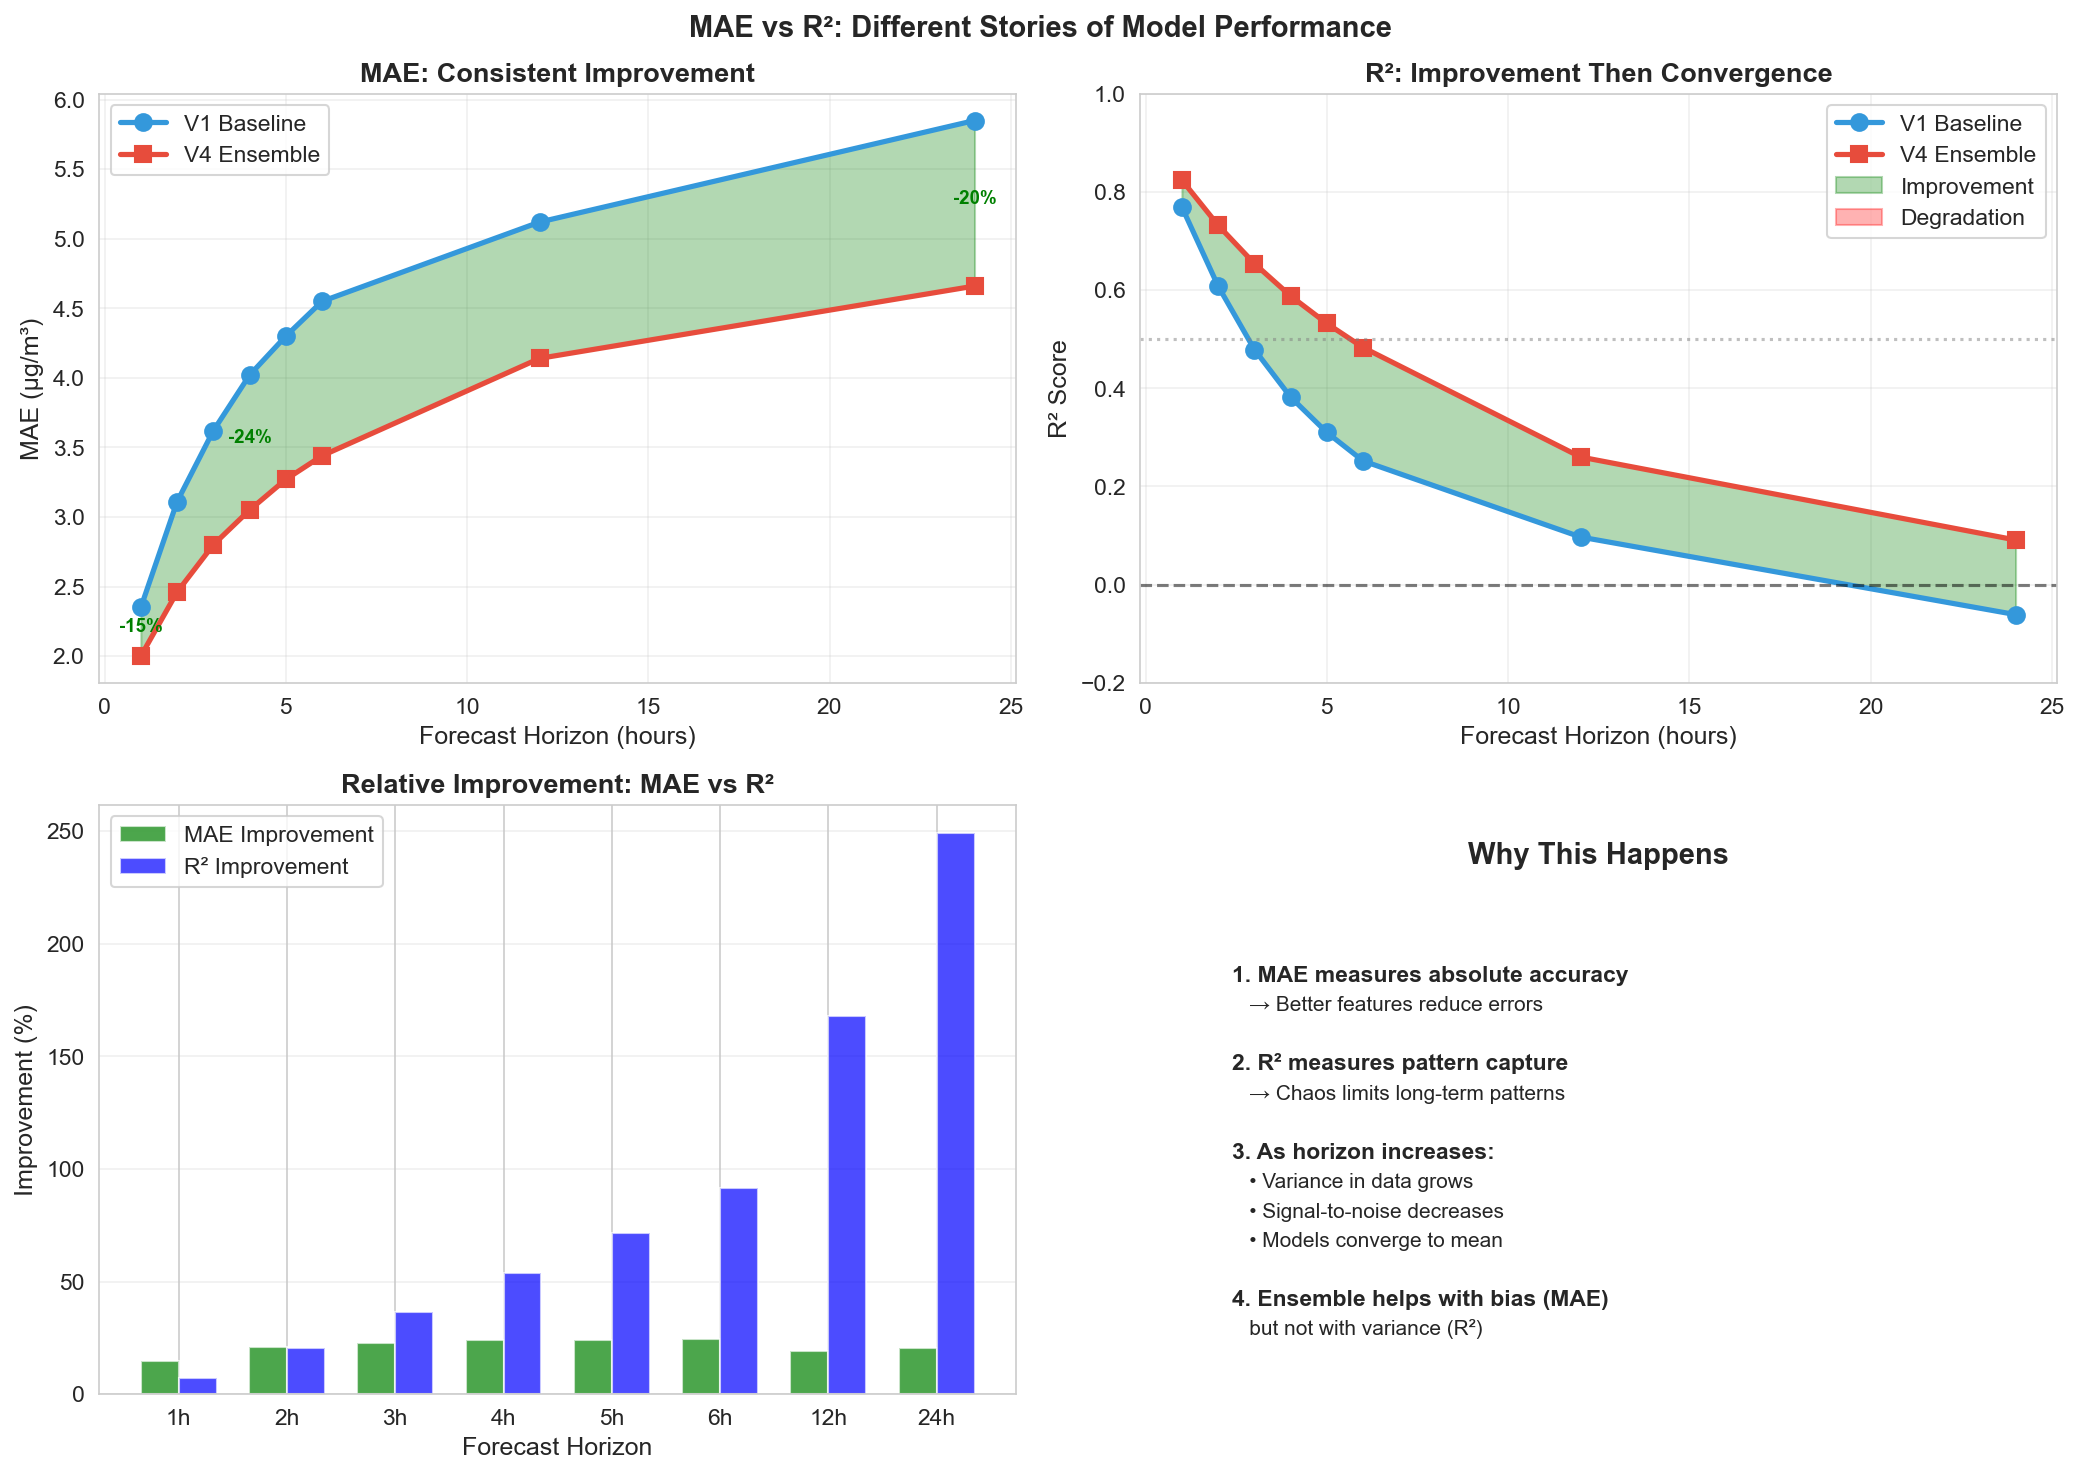

In [4]:
horizons = [1, 2, 3, 4, 5, 6, 12, 24]

mae_v1 = [2.35, 3.11, 3.62, 4.02, 4.30, 4.55, 5.12, 5.85]
mae_v4 = [2.00, 2.46, 2.80, 3.05, 3.27, 3.44, 4.14, 4.66]

r2_v1 = [0.769, 0.608, 0.479, 0.382, 0.310, 0.252, 0.097, -0.061]
r2_v4 = [0.824, 0.732, 0.654, 0.588, 0.532, 0.483, 0.260, 0.091]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(horizons, mae_v1, 'o-', linewidth=2.5, markersize=8, label='V1 Baseline', color='#3498DB')
ax.plot(horizons, mae_v4, 's-', linewidth=2.5, markersize=8, label='V4 Ensemble', color='#E74C3C')
ax.fill_between(horizons, mae_v1, mae_v4, alpha=0.3, color='green')
ax.set_xlabel('Forecast Horizon (hours)', fontsize=12)
ax.set_ylabel('MAE (μg/m³)', fontsize=12)
ax.set_title('MAE: Consistent Improvement', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
for i in [0, 3, 7]:
    improvement = (mae_v1[i] - mae_v4[i]) / mae_v1[i] * 100
    ax.annotate(f'-{improvement:.0f}%', 
               xy=(horizons[i], (mae_v1[i] + mae_v4[i])/2),
               fontsize=9, ha='center', color='green', fontweight='bold')

ax = axes[0, 1]
ax.plot(horizons, r2_v1, 'o-', linewidth=2.5, markersize=8, label='V1 Baseline', color='#3498DB')
ax.plot(horizons, r2_v4, 's-', linewidth=2.5, markersize=8, label='V4 Ensemble', color='#E74C3C')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
ax.fill_between(horizons, r2_v1, r2_v4, where=[r2_v4[i] > r2_v1[i] for i in range(len(horizons))], 
                alpha=0.3, color='green', label='Improvement')
ax.fill_between(horizons, r2_v1, r2_v4, where=[r2_v4[i] <= r2_v1[i] for i in range(len(horizons))], 
                alpha=0.3, color='red', label='Degradation')
ax.set_xlabel('Forecast Horizon (hours)', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('R²: Improvement Then Convergence', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.2, 1.0)

ax = axes[1, 0]
improvement_mae = [(mae_v1[i] - mae_v4[i]) / mae_v1[i] * 100 for i in range(len(horizons))]
improvement_r2 = [(r2_v4[i] - r2_v1[i]) / abs(r2_v1[i]) * 100 if r2_v1[i] != 0 else 0 
                  for i in range(len(horizons))]

width = 0.35
x = np.arange(len(horizons))
bars1 = ax.bar(x - width/2, improvement_mae, width, label='MAE Improvement', color='green', alpha=0.7)
bars2 = ax.bar(x + width/2, improvement_r2, width, label='R² Improvement', color='blue', alpha=0.7)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Forecast Horizon', fontsize=12)
ax.set_ylabel('Improvement (%)', fontsize=12)
ax.set_title('Relative Improvement: MAE vs R²', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{h}h' for h in horizons])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.text(0.5, 0.9, 'Why This Happens', fontsize=14, fontweight='bold', ha='center')

reasons = [
    "1. MAE measures absolute accuracy",
    "   → Better features reduce errors",
    "",
    "2. R² measures pattern capture",
    "   → Chaos limits long-term patterns",
    "",
    "3. As horizon increases:",
    "   • Variance in data grows",
    "   • Signal-to-noise decreases",
    "   • Models converge to mean",
    "",
    "4. Ensemble helps with bias (MAE)",
    "   but not with variance (R²)"
]

y_pos = 0.7
for reason in reasons:
    if reason.startswith(('1.', '2.', '3.', '4.')):
        ax.text(0.1, y_pos, reason, fontsize=11, fontweight='bold')
    else:
        ax.text(0.1, y_pos, reason, fontsize=10)
    y_pos -= 0.05

plt.suptitle('MAE vs R²: Different Stories of Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphs/mae_r2_degradation_explained.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/mae_r2_degradation_explained.png")
plt.show()

## 4. Residual Analysis: What Each Metric Captures

Saved: graphs/residual_analysis.png


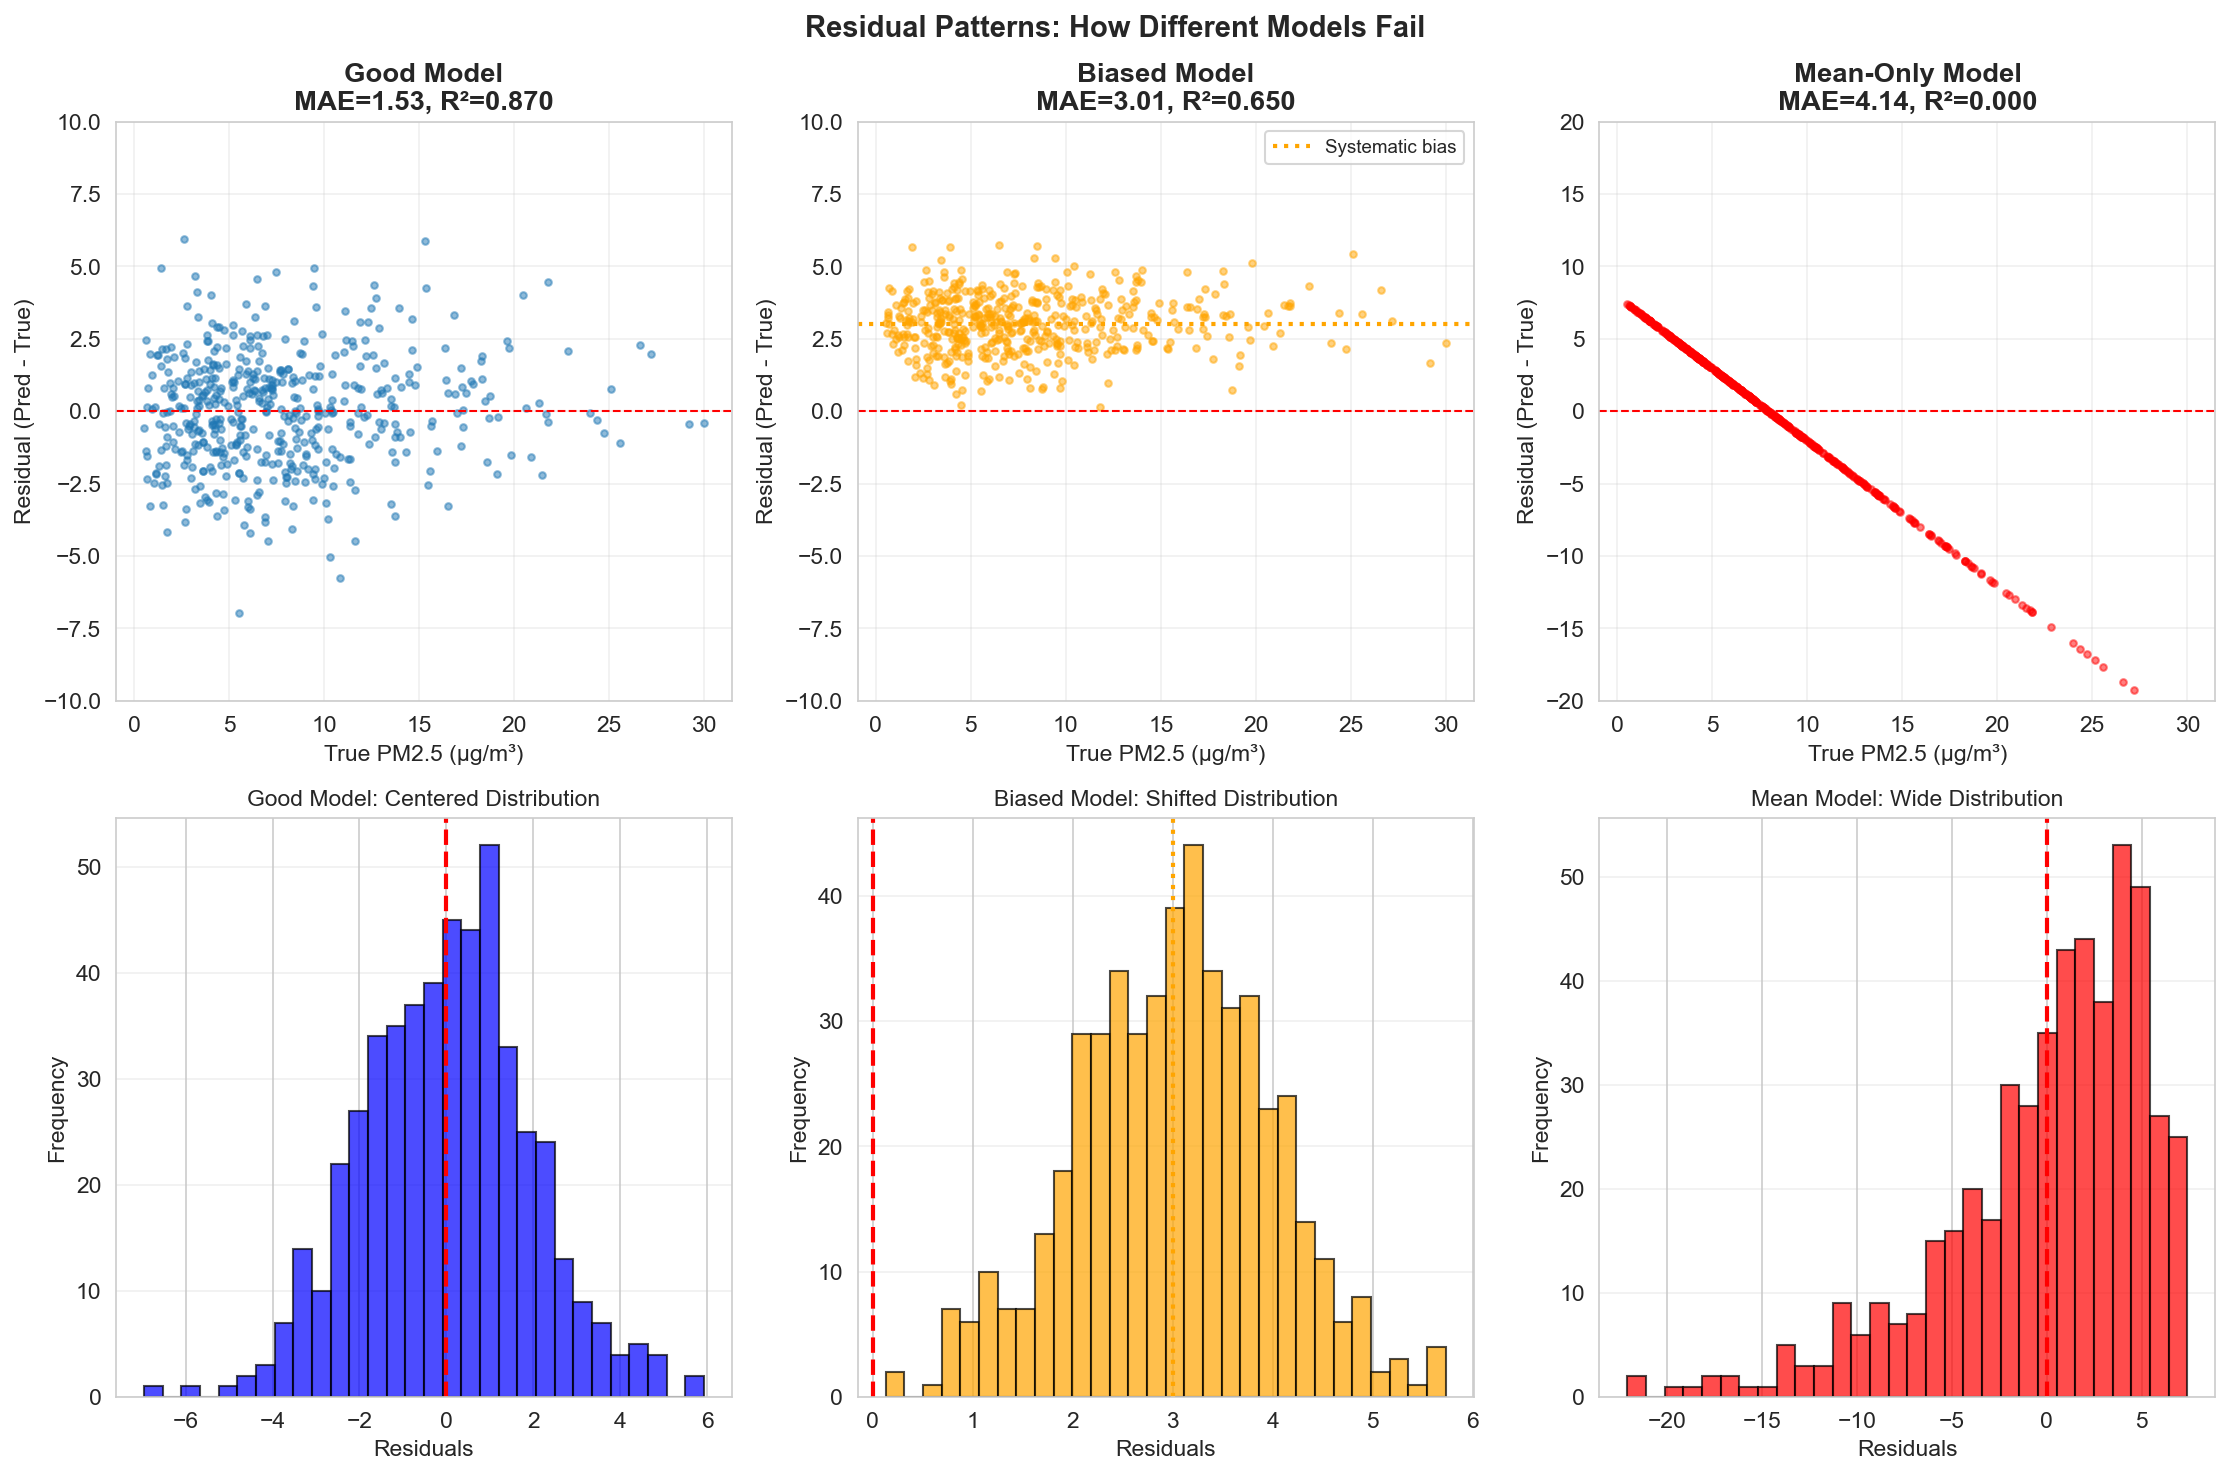

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

np.random.seed(42)
n = 500

true_values = np.random.gamma(2, 4, n)
true_values = np.clip(true_values, 0, 30)

good_predictions = true_values + np.random.normal(0, 2, n)
good_mae = mean_absolute_error(true_values, good_predictions)
good_r2 = r2_score(true_values, good_predictions)

ax = axes[0, 0]
ax.scatter(true_values, good_predictions - true_values, alpha=0.5, s=10)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('True PM2.5 (μg/m³)')
ax.set_ylabel('Residual (Pred - True)')
ax.set_title(f'Good Model\nMAE={good_mae:.2f}, R²={good_r2:.3f}', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(-10, 10)

biased_predictions = true_values + 3 + np.random.normal(0, 1, n)
biased_mae = mean_absolute_error(true_values, biased_predictions)
biased_r2 = r2_score(true_values, biased_predictions)

ax = axes[0, 1]
ax.scatter(true_values, biased_predictions - true_values, alpha=0.5, s=10, color='orange')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax.axhline(y=3, color='orange', linestyle=':', linewidth=2, label='Systematic bias')
ax.set_xlabel('True PM2.5 (μg/m³)')
ax.set_ylabel('Residual (Pred - True)')
ax.set_title(f'Biased Model\nMAE={biased_mae:.2f}, R²={biased_r2:.3f}', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(-10, 10)

mean_pred = np.ones(n) * np.mean(true_values)
mean_mae = mean_absolute_error(true_values, mean_pred)
mean_r2 = r2_score(true_values, mean_pred)

ax = axes[0, 2]
ax.scatter(true_values, mean_pred - true_values, alpha=0.5, s=10, color='red')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('True PM2.5 (μg/m³)')
ax.set_ylabel('Residual (Pred - True)')
ax.set_title(f'Mean-Only Model\nMAE={mean_mae:.2f}, R²={mean_r2:.3f}', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(-20, 20)

ax = axes[1, 0]
ax.hist(good_predictions - true_values, bins=30, alpha=0.7, color='blue', edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Residuals')
ax.set_ylabel('Frequency')
ax.set_title('Good Model: Centered Distribution', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
ax.hist(biased_predictions - true_values, bins=30, alpha=0.7, color='orange', edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.axvline(x=3, color='orange', linestyle=':', linewidth=2)
ax.set_xlabel('Residuals')
ax.set_ylabel('Frequency')
ax.set_title('Biased Model: Shifted Distribution', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 2]
ax.hist(mean_pred - true_values, bins=30, alpha=0.7, color='red', edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Residuals')
ax.set_ylabel('Frequency')
ax.set_title('Mean Model: Wide Distribution', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Residual Patterns: How Different Models Fail', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphs/residual_analysis.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/residual_analysis.png")
plt.show()

## 5. The Key Insight: Variance vs Accuracy

Saved: graphs/signal_vs_noise.png


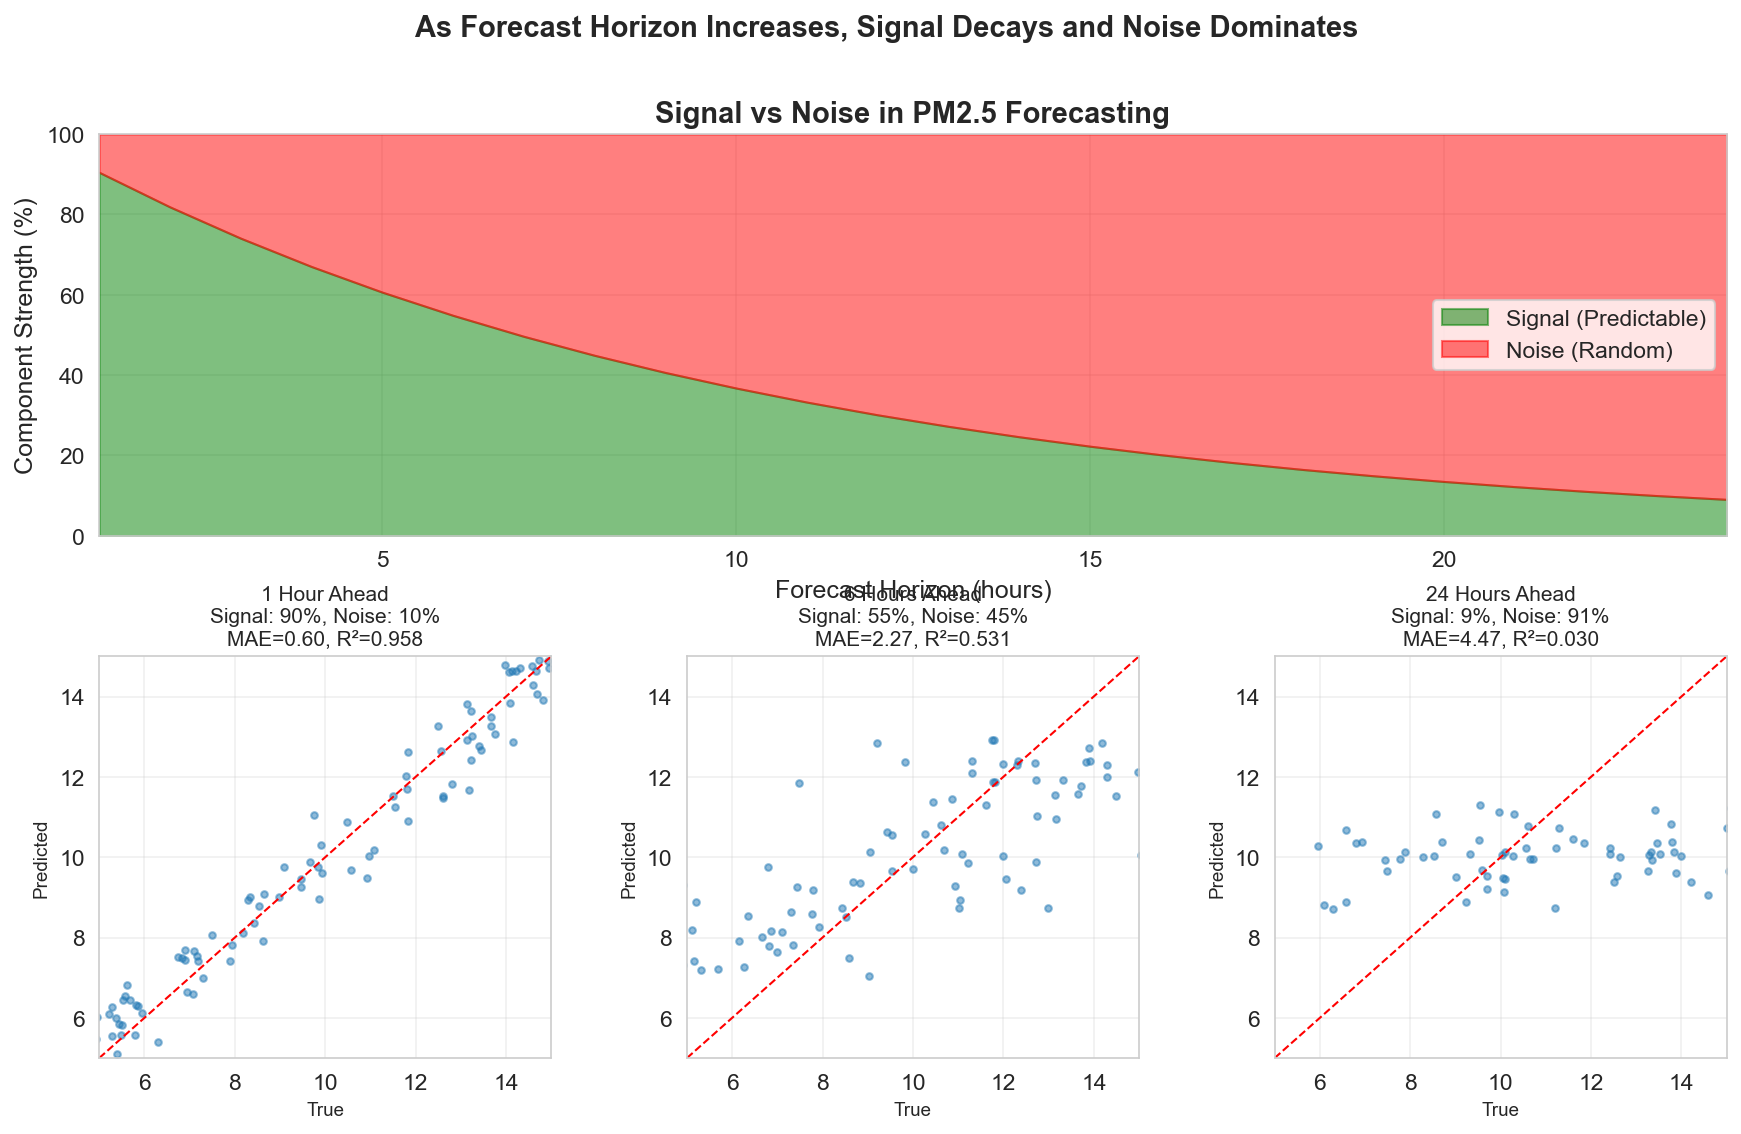

In [6]:
fig = plt.figure(figsize=(14, 8))

gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])

horizons_detailed = np.linspace(1, 24, 24)
signal_strength = 100 * np.exp(-horizons_detailed / 10)
noise_strength = 100 - signal_strength

ax1.fill_between(horizons_detailed, 0, signal_strength, alpha=0.5, color='green', label='Signal (Predictable)')
ax1.fill_between(horizons_detailed, signal_strength, 100, alpha=0.5, color='red', label='Noise (Random)')
ax1.set_xlabel('Forecast Horizon (hours)', fontsize=12)
ax1.set_ylabel('Component Strength (%)', fontsize=12)
ax1.set_title('Signal vs Noise in PM2.5 Forecasting', fontsize=14, fontweight='bold')
ax1.legend(loc='right', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1, 24)
ax1.set_ylim(0, 100)

for h, ax, title in [(1, ax2, '1 Hour Ahead'), (6, ax3, '6 Hours Ahead'), (24, ax4, '24 Hours Ahead')]:
    signal_pct = 100 * np.exp(-h / 10)
    noise_pct = 100 - signal_pct
    
    y_true = 10 + 5 * np.sin(np.linspace(0, 4*np.pi, 100))
    noise = np.random.normal(0, noise_pct/20, 100)
    y_with_noise = y_true + noise
    
    y_pred = y_true * (signal_pct/100) + np.mean(y_true) * (noise_pct/100)
    y_pred += np.random.normal(0, 0.5, 100)
    
    ax.scatter(y_with_noise, y_pred, alpha=0.5, s=10)
    ax.plot([5, 15], [5, 15], 'r--', lw=1)
    
    mae = mean_absolute_error(y_with_noise, y_pred)
    r2 = r2_score(y_with_noise, y_pred)
    
    ax.set_title(f'{title}\nSignal: {signal_pct:.0f}%, Noise: {noise_pct:.0f}%\nMAE={mae:.2f}, R²={r2:.3f}', 
                fontsize=10)
    ax.set_xlabel('True', fontsize=9)
    ax.set_ylabel('Predicted', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(5, 15)
    ax.set_ylim(5, 15)

plt.suptitle('As Forecast Horizon Increases, Signal Decays and Noise Dominates', 
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphs/signal_vs_noise.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/signal_vs_noise.png")
plt.show()

## 6. Summary: Key Takeaways

Saved: graphs/mse_r2_key_takeaways.png


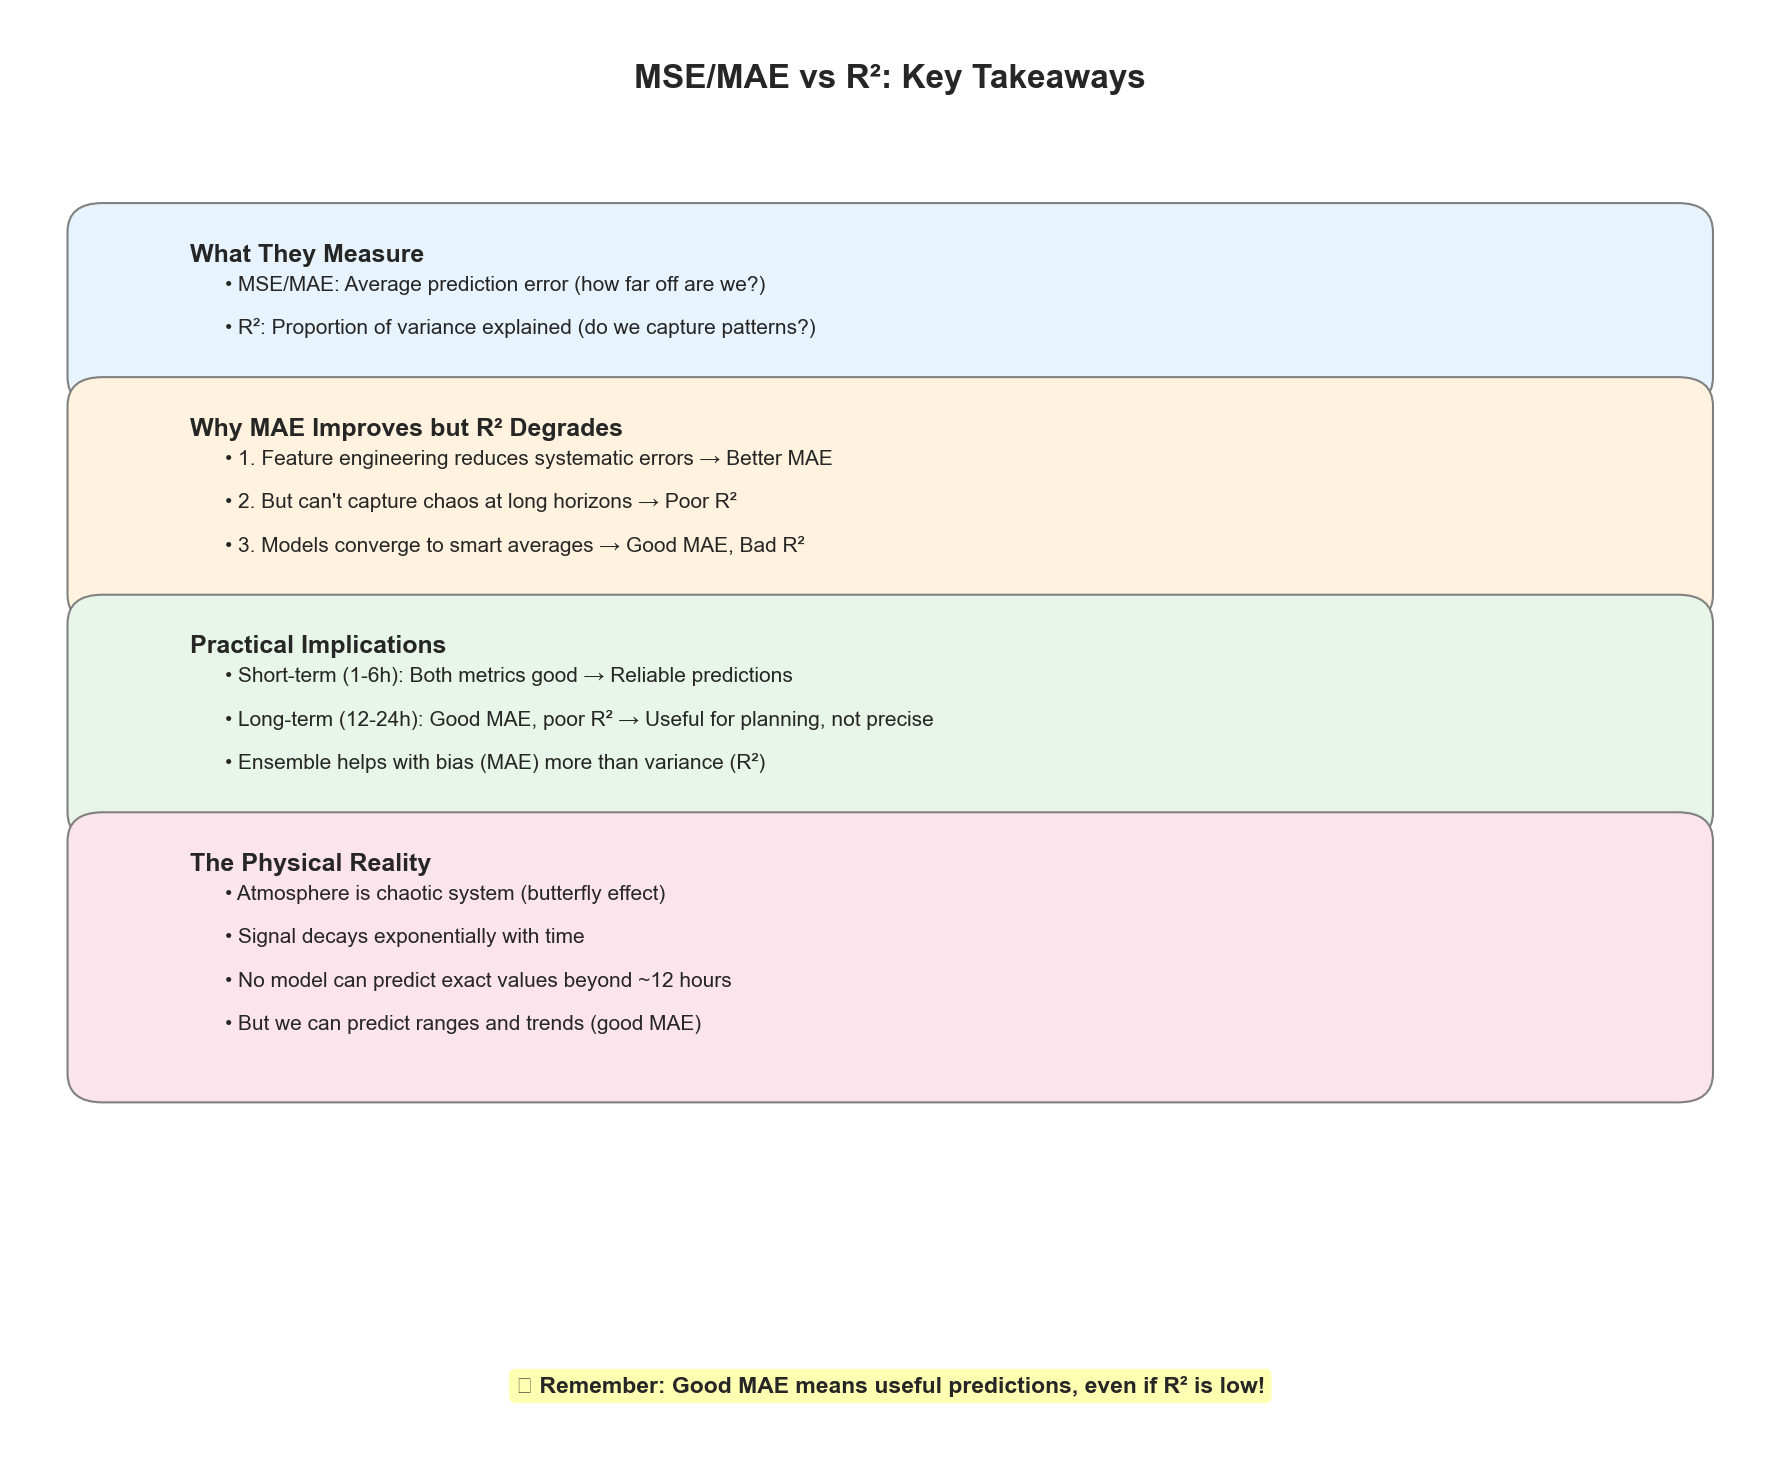

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.text(0.5, 0.95, 'MSE/MAE vs R²: Key Takeaways', 
       fontsize=16, fontweight='bold', ha='center')

sections = [
    ("What They Measure", [
        "MSE/MAE: Average prediction error (how far off are we?)",
        "R²: Proportion of variance explained (do we capture patterns?)"
    ], '#E8F4FD'),
    
    ("Why MAE Improves but R² Degrades", [
        "1. Feature engineering reduces systematic errors → Better MAE",
        "2. But can't capture chaos at long horizons → Poor R²",
        "3. Models converge to smart averages → Good MAE, Bad R²"
    ], '#FFF3E0'),
    
    ("Practical Implications", [
        "Short-term (1-6h): Both metrics good → Reliable predictions",
        "Long-term (12-24h): Good MAE, poor R² → Useful for planning, not precise",
        "Ensemble helps with bias (MAE) more than variance (R²)"
    ], '#E8F5E9'),
    
    ("The Physical Reality", [
        "Atmosphere is chaotic system (butterfly effect)",
        "Signal decays exponentially with time",
        "No model can predict exact values beyond ~12 hours",
        "But we can predict ranges and trends (good MAE)"
    ], '#FCE4EC')
]

y_pos = 0.85
for title, points, color in sections:
    height = 0.04 + 0.03 * len(points)
    rect = FancyBboxPatch((0.05, y_pos - height), 0.9, height,
                          boxstyle="round,pad=0.02",
                          facecolor=color, edgecolor='gray', linewidth=1)
    ax.add_patch(rect)
    
    ax.text(0.1, y_pos - 0.02, title, fontsize=12, fontweight='bold')
    
    point_y = y_pos - 0.04
    for point in points:
        ax.text(0.12, point_y, f"• {point}", fontsize=10)
        point_y -= 0.03
    
    y_pos -= height + 0.02

ax.text(0.5, 0.05, 
       "💡 Remember: Good MAE means useful predictions, even if R² is low!",
       ha='center', fontsize=11, fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.savefig('graphs/mse_r2_key_takeaways.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/mse_r2_key_takeaways.png")
plt.show()

## 7. Interactive Comparison: Your Models

In [ ]:
model_comparison = pd.DataFrame({
    'Model': ['V1 Baseline', 'V4 Baseline', 'V4 Ensemble'],
    'Description': [
        'Linear Regression (PM2.5 only)',
        'Linear Regression (+ features)',
        'XGB + LGB + CatBoost'
    ],
    '1h MAE': [2.35, 2.08, 2.00],
    '1h R²': [0.769, 0.845, 0.824],
    '24h MAE': [5.85, 4.84, 4.66],
    '24h R²': [-0.061, 0.201, 0.091]
})

print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(model_comparison.to_string(index=False))

print("\n" + "="*70)
print("KEY INSIGHTS FOR PRESENTATION")
print("="*70)
print("""
1. MAE CONSISTENTLY IMPROVES
   - V1 → V4: Feature engineering works!
   - Ensemble: Additional gains from model diversity
   - Practical impact: ±2 μg/m³ at 1h is excellent

2. R² TELLS A DIFFERENT STORY
   - Improves for short-term (more signal)
   - Degrades for long-term (more noise)
   - V4 Ensemble R² < V4 Baseline at 1h (overfitting?)

3. WHY THIS ISN'T FAILURE
   - MAE = "Are we close?" → YES
   - R² = "Do we explain variance?" → Less over time
   - Real world: Trends matter more than exact values

4. RECOMMENDATION
   - Use MAE for model selection
   - Report R² for transparency
   - Focus on prediction intervals for long horizons
""")


MODEL COMPARISON SUMMARY
      Model                    Description  1h MAE  1h R²  24h MAE  24h R²
V1 Baseline Linear Regression (PM2.5 only)    2.35  0.769     5.85  -0.061
V4 Baseline Linear Regression (+ features)    2.08  0.845     4.84   0.201
V4 Ensemble           XGB + LGB + CatBoost    2.00  0.824     4.66   0.091

KEY INSIGHTS FOR PRESENTATION

1. MAE CONSISTENTLY IMPROVES
   - V1 → V4: Feature engineering works!
   - Ensemble: Additional gains from model diversity
   - Practical impact: ±2 μg/m³ at 1h is excellent

2. R² TELLS A DIFFERENT STORY
   - Improves for short-term (more signal)
   - Degrades for long-term (more noise)
   - V4 Ensemble R² < V4 Baseline at 1h (overfitting?)

3. WHY THIS ISN'T FAILURE
   - MAE = "Are we close?" → YES
   - R² = "Do we explain variance?" → Less over time
   - Real world: Trends matter more than exact values

4. RECOMMENDATION
   - Use MAE for model selection
   - Report R² for transparency
   - Focus on prediction intervals for long hor

: 

## Summary

This notebook generated 6 key visualizations for your presentation:

1. **mse_r2_definitions.png** - Mathematical definitions and interpretations
2. **mse_vs_r2_examples.png** - Visual examples of different MSE/R² combinations
3. **mae_r2_degradation_explained.png** - Why your models show this pattern
4. **residual_analysis.png** - What different types of errors look like
5. **signal_vs_noise.png** - How signal decays with forecast horizon
6. **mse_r2_key_takeaways.png** - Summary slide for presentation

**Main Message:** Good MAE with degrading R² is not failure - it's physics. Your models are getting better at prediction magnitude (MAE) even though they can't capture all variance (R²) at long horizons.